In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")

In [2]:
# Dataset A: Symmetric
dataset_A = np.random.normal(loc=50, scale=10, size=500)

# Dataset B: Right-skewed
dataset_B = np.random.exponential(scale=20, size=500)  # scale=1/lambda
dataset_B = dataset_B - dataset_B.min()  # сдвиг к 0
dataset_B = dataset_B / dataset_B.max() * 100  # масштабируем к 0-100

# Dataset C: Bimodal
dataset_C1 = np.random.normal(loc=30, scale=5, size=250)
dataset_C2 = np.random.normal(loc=70, scale=5, size=250)
dataset_C = np.concatenate([dataset_C1, dataset_C2])

In [3]:
def summarize_dataset(data):
    mean = np.mean(data)
    median = np.median(data)
    # Новый способ получения моды
    mode_result = stats.mode(np.round(data, 2), keepdims=True)
    mode_val = mode_result.mode[0]  # берём первый элемент
    std = np.std(data, ddof=1)
    var = np.var(data, ddof=1)
    skew_val = stats.skew(data)
    kurt = stats.kurtosis(data)

    return {
        "Mean": round(mean, 2),
        "Median": round(median, 2),
        "Mode": round(mode_val, 2),
        "Std": round(std, 2),
        "Var": round(var, 2),
        "Skewness": round(skew_val, 2),
        "Kurtosis": round(kurt, 2)
    }

# Создаем таблицу
summary_table = pd.DataFrame({
    "Dataset A": summarize_dataset(dataset_A),
    "Dataset B": summarize_dataset(dataset_B),
    "Dataset C": summarize_dataset(dataset_C)
})

summary_table = summary_table.T
summary_table

,Mean,Median,Mode,Std,Var,Skewness,Kurtosis
Dataset A,50.07,50.13,34.85,9.81,96.29,0.18,0.26
Dataset B,16.17,11.29,0.14,15.99,255.64,1.77,3.98
Dataset C,50.33,49.53,24.89,20.30,412.02,0.01,-1.76


# Descriptive Statistics Summary

We compute key descriptive statistics (mean, median, mode, std, variance, skewness, kurtosis) for each dataset to summarize its central tendency, variability, and distribution shape.

```python
summary_table = pd.DataFrame({
    "Dataset A": summarize_dataset(dataset_A),
    "Dataset B": summarize_dataset(dataset_B),
    "Dataset C": summarize_dataset(dataset_C)
}).T

summary_table

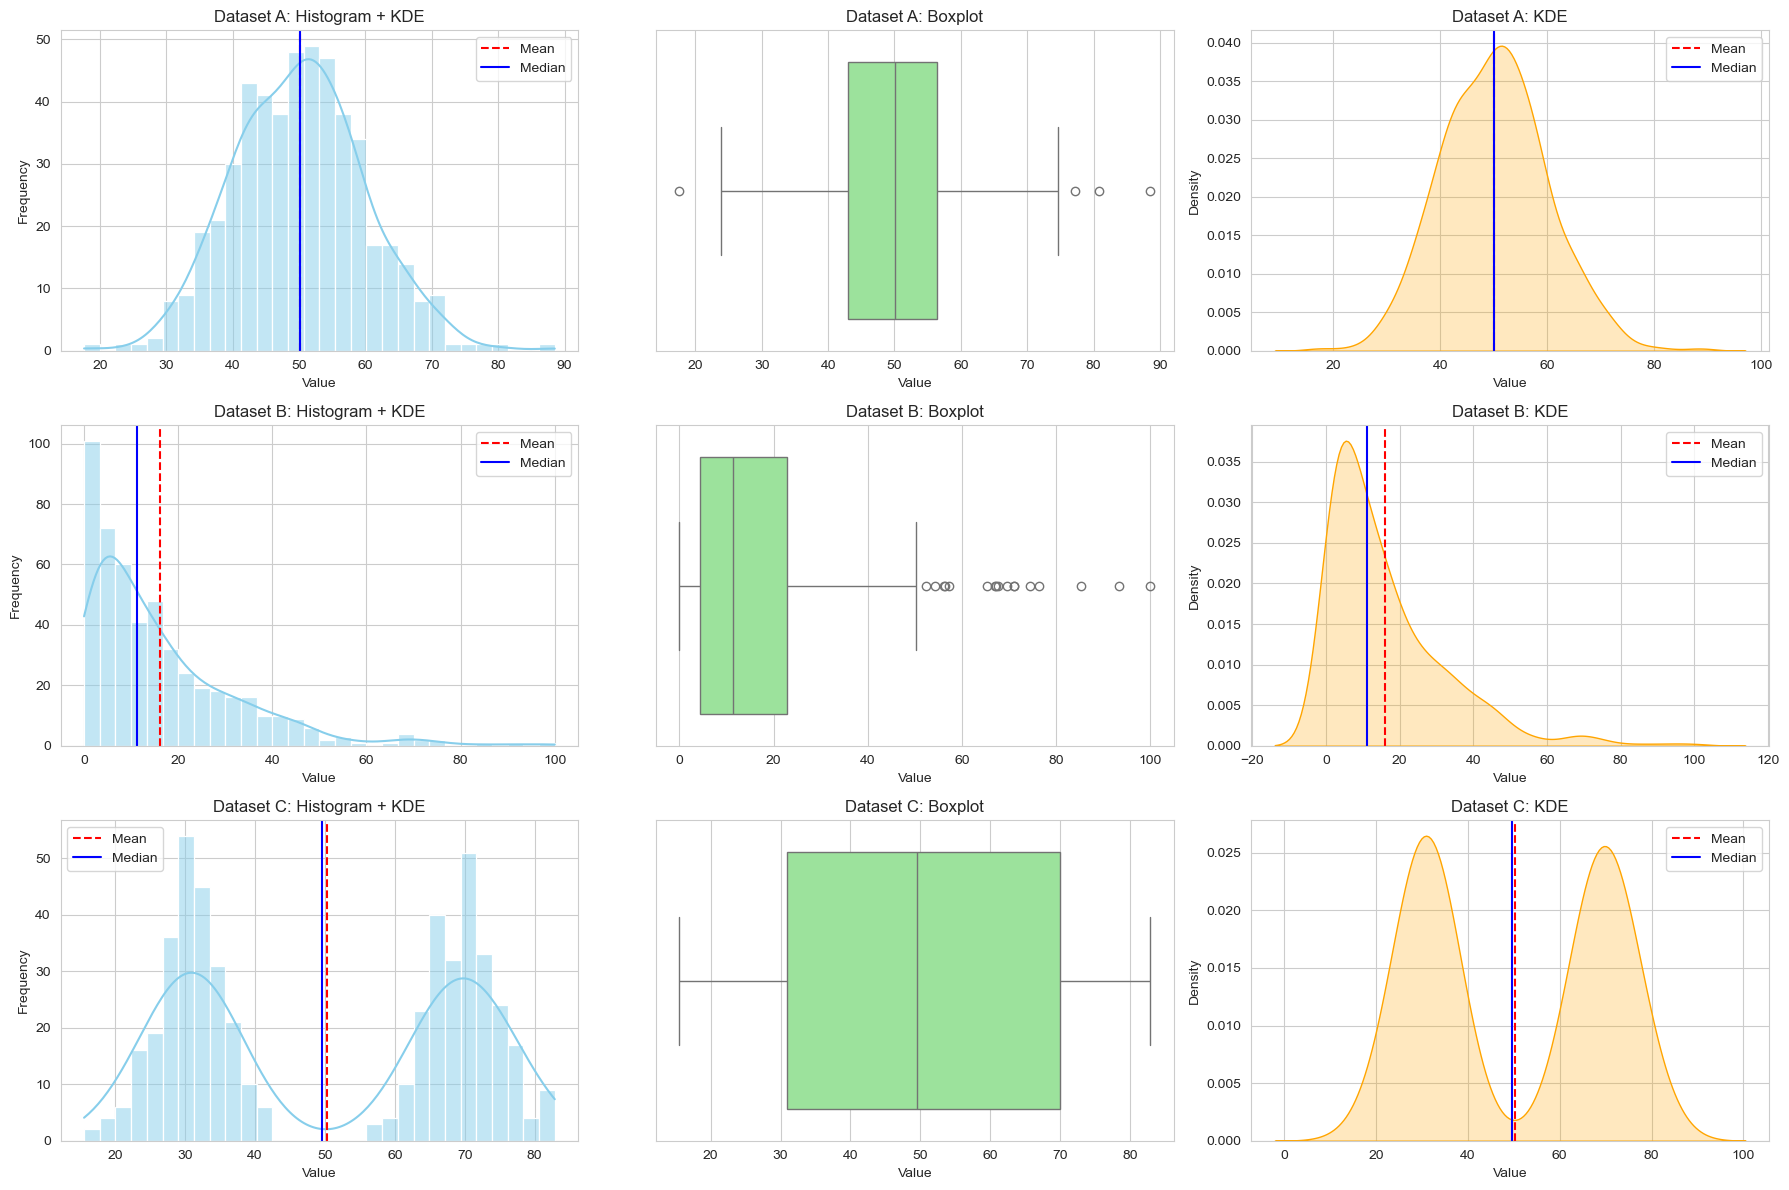

In [4]:
datasets = [dataset_A, dataset_B, dataset_C]
dataset_names = ["Dataset A", "Dataset B", "Dataset C"]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for i, data in enumerate(datasets):
    mean_val = np.mean(data)
    median_val = np.median(data)
    
    # Histogram + KDE
    sns.histplot(data, bins=30, kde=True, ax=axes[i, 0], color='skyblue', edgecolor='white')
    axes[i, 0].axvline(mean_val, color='red', linestyle='--', label='Mean')
    axes[i, 0].axvline(median_val, color='blue', linestyle='-', label='Median')
    axes[i, 0].set_title(f"{dataset_names[i]}: Histogram + KDE")
    axes[i, 0].set_xlabel("Value")
    axes[i, 0].set_ylabel("Frequency")
    axes[i, 0].legend()

    # Boxplot
    sns.boxplot(x=data, ax=axes[i, 1], orient='h', color='lightgreen')
    axes[i, 1].set_title(f"{dataset_names[i]}: Boxplot")
    axes[i, 1].set_xlabel("Value")

    # KDE only
    sns.kdeplot(data, ax=axes[i, 2], fill=True, color='orange')
    axes[i, 2].axvline(mean_val, color='red', linestyle='--', label='Mean')
    axes[i, 2].axvline(median_val, color='blue', linestyle='-', label='Median')
    axes[i, 2].set_title(f"{dataset_names[i]}: KDE")
    axes[i, 2].set_xlabel("Value")
    axes[i, 2].set_ylabel("Density")
    axes[i, 2].legend()

plt.tight_layout()
plt.show()

- Compare the mean (red dashed) and median (blue solid) lines in the plots.
- **Dataset(s) with largest mean-median divergence:** Likely the dataset(s) with **skewed distribution**.
    - Positive/right skew → mean > median (long right tail)
    - Negative/left skew → mean < median (long left tail)
- The divergence is visually confirmed in:
    - Histogram/KDE: long tail on one side.
    - Boxplot: median not centered in the box.

,Mean,Median,Mode,Std,Variance,Skewness,Kurtosis
Original A,50.07,50.13,34.85,9.81,96.29,0.18,0.26
Modified A,57.17,50.13,34.85,74.38,5532.48,9.70,94.18


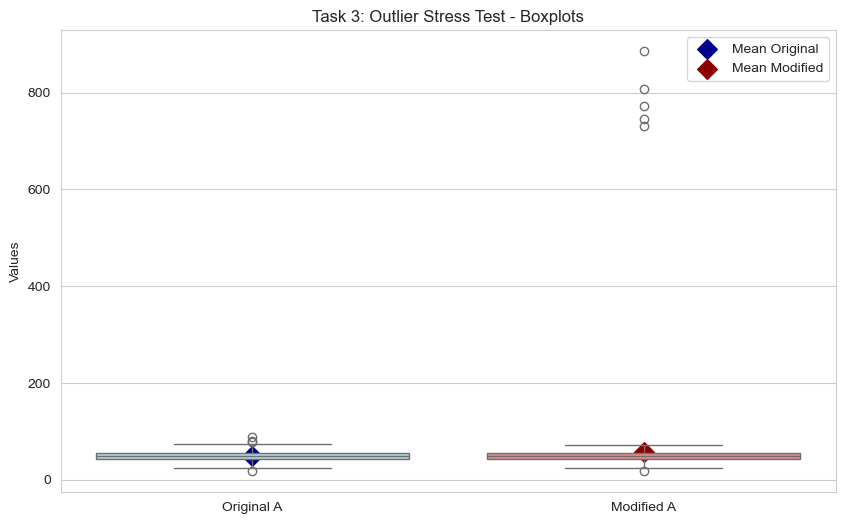

In [5]:
# Create a modified copy of Dataset A
dataset_A_modified = dataset_A.copy()
top_5_indices = np.argsort(dataset_A_modified)[-5:]
dataset_A_modified[top_5_indices] *= 10  # multiply top 5 values by 10

# Function from Task 1 for summary statistics
from scipy import stats

def summarize_dataset(data):
    mean = np.mean(data)
    median = np.median(data)
    
    # Compute mode safely
    mode_result = stats.mode(np.round(data, 2), keepdims=True)  # always 1D
    if hasattr(mode_result.mode, '__len__') and len(mode_result.mode) > 0:
        mode_val = mode_result.mode[0]
    else:
        mode_val = mean  # fallback if mode cannot be determined

    std = np.std(data, ddof=1)
    var = np.var(data, ddof=1)
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)
    
    return {
        "Mean": round(mean, 2),
        "Median": round(median, 2),
        "Mode": round(mode_val, 2),
        "Std": round(std, 2),
        "Variance": round(var, 2),
        "Skewness": round(skew, 2),
        "Kurtosis": round(kurt, 2)
    }

# Create summary table
summary_outlier_table = pd.DataFrame({
    "Original A": summarize_dataset(dataset_A),
    "Modified A": summarize_dataset(dataset_A_modified)
}).T

display(summary_outlier_table)

# Side-by-side boxplots
plt.figure(figsize=(10,6))
sns.boxplot(data=[dataset_A, dataset_A_modified], palette=['lightblue','lightcoral'])
plt.xticks([0,1], ['Original A', 'Modified A'])
plt.title("Task 3: Outlier Stress Test - Boxplots")
plt.ylabel("Values")

# Overlay mean as diamond marker
plt.scatter([0]*len([np.mean(dataset_A)]), [np.mean(dataset_A)], color='darkblue', marker='D', s=100, label='Mean Original')
plt.scatter([1]*len([np.mean(dataset_A_modified)]), [np.mean(dataset_A_modified)], color='darkred', marker='D', s=100, label='Mean Modified')
plt.legend()
plt.show()

# Task 3: Outlier Stress Test Observations

- **Statistics most affected:** Mean, Standard Deviation, Variance, Skewness, Kurtosis — all increased due to extreme outliers.
- **Robust statistics:** Median and Mode remained nearly unchanged, showing resistance to outliers.
- **Typical value choice for modified dataset:** Use **median**, not mean, because the mean is heavily skewed by extreme values. The median better represents the "central" tendency of the majority of the data.